In [1]:
!pip install opencv-python

     --------------------------------------- 40.2/40.2 MB 11.7 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



Running the 4-stage visibility improvement pipeline on 'C:\Users\VICKKY\Documents\SB jain\7thsem\Machine-Vision\Machine_Vision_Lab\Practical1\moon.jpg'...

Processing complete! File saved as: c:\Users\VICKKY\Documents\SB jain\7thsem\Machine-Vision\Machine_Vision_Lab\Practical1\enhanced_cctv_output.jpg


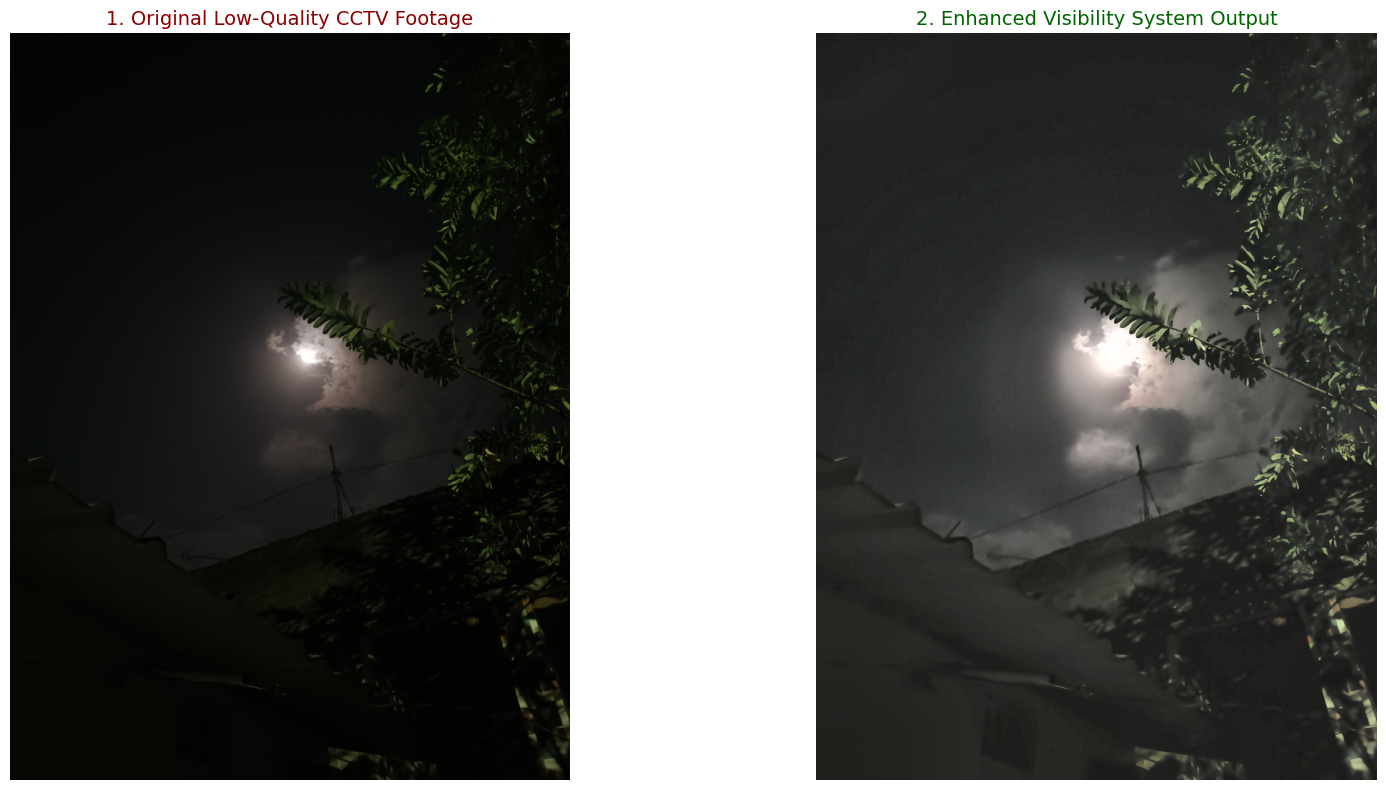

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path


def find_image_path(image_name):
    """Locate an image file from several likely locations."""
    input_path = Path(image_name).expanduser()
    candidates = []

    # Directly as provided
    candidates.append(input_path)

    # Relative to current working directory
    candidates.append(Path.cwd() / input_path)

    # Relative to the notebook/practical folder
    practical_dir = Path.cwd() / "Practical1"
    candidates.append(practical_dir / input_path)
    candidates.append(practical_dir / image_name)

    # If the notebook is executed from the workspace root, look in subfolders too
    for candidate in Path.cwd().rglob(image_name):
        if candidate.is_file():
            candidates.append(candidate)

    # If this is being run as a script, also check the script's directory
    if "__file__" in globals():
        script_dir = Path(__file__).resolve().parent
        candidates.append(script_dir / input_path)
        candidates.append(script_dir / image_name)

    seen = set()
    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved.exists() and resolved.is_file() and resolved not in seen:
            seen.add(resolved)
            return str(resolved)

    return None


def cctv_enhancement_system(image_path):
    # Load the original low-quality image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read the image from path: {image_path}")
        print(f"Current Working Directory: {os.getcwd()}")
        return

    # Convert to LAB color space to process luminance (L) without distorting colors
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    # -----------------------------------------------------------------
    # TECHNIQUE 1: NOISE REMOVAL
    # -----------------------------------------------------------------
    # Uses Non-Local Means Denoising to eliminate low-light sensor grain
    # while preserving structural edges.
    noise_removed_l = cv2.fastNlMeansDenoising(
        src=l_channel,
        dst=None,
        h=12,
        templateWindowSize=7,
        searchWindowSize=21
    )

    # -----------------------------------------------------------------
    # TECHNIQUE 2: HISTOGRAM EQUALIZATION
    # -----------------------------------------------------------------
    # Uses Contrast Limited Adaptive Histogram Equalization (CLAHE)
    # to distribute contrast evenly across local regions.
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    equalized_l = clahe.apply(noise_removed_l)

    # -----------------------------------------------------------------
    # TECHNIQUE 3: BRIGHTNESS ENHANCEMENT
    # -----------------------------------------------------------------
    # Multiplies and offsets pixel intensities to lift shadow details.
    # alpha = contrast scaling (1.1), beta = brightness offset (+20)
    brightened_l = cv2.convertScaleAbs(equalized_l, alpha=1.1, beta=20)

    # Recombine the processed Lightness channel with original color channels
    enhanced_lab = cv2.merge((brightened_l, a_channel, b_channel))
    enhanced_bgr = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

    # -----------------------------------------------------------------
    # TECHNIQUE 4: FILTERING (Spatial Domain Sharpening)
    # -----------------------------------------------------------------
    # Uses a high-pass kernel filter via 2D convolution to sharpen
    # fine forensic details like edges, objects, and text.
    sharpen_kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])
    final_output = cv2.filter2D(src=enhanced_bgr, ddepth=-1, kernel=sharpen_kernel)

    # Save the final forensic image
    output_filename = 'enhanced_cctv_output.jpg'
    cv2.imwrite(output_filename, final_output)
    print(f"\nProcessing complete! File saved as: {os.path.abspath(output_filename)}")

    # -----------------------------------------------------------------
    # VISUALIZATION OF THE PIPELINE RESULTS
    # -----------------------------------------------------------------
    plt.figure(figsize=(18, 8))

    # Subplot 1: Original Input
    plt.subplot(1, 2, 1)
    plt.title("1. Original Low-Quality CCTV Footage", fontsize=14, color='darkred')
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # Subplot 2: Enhanced Output
    plt.subplot(1, 2, 2)
    plt.title("2. Enhanced Visibility System Output", fontsize=14, color='darkgreen')
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# =====================================================================
# EXECUTION BLOCK (AUTOMATED FOR MOON.JPG)
# =====================================================================
if __name__ == "__main__":
    target_image = "moon.jpg"
    resolved_image = find_image_path(target_image)

    if resolved_image:
        print(f"\nRunning the 4-stage visibility improvement pipeline on '{resolved_image}'...")
        cctv_enhancement_system(resolved_image)
    else:
        print(f"Error: Could not find '{target_image}' in the current directory or its subfolders.")
        print(f"Checked locations relative to: {os.path.abspath('.')}")
        print("Please ensure the image file is physically inside the folder you opened in VS Code.")